In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

# Load and resize
img_left  = cv2.imread('data/Motorcycle-perfect/im0.png')
img_right = cv2.imread('data/Motorcycle-perfect/im1.png')
img_left  = cv2.resize(img_left,  (741, 500))
img_right = cv2.resize(img_right, (741, 500))

gray_left  = cv2.cvtColor(img_left,  cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

num_disparities = 64  # move to 96 once the pipeline is working
block_size = 5        # patch size, odd number

# Camera parameters
scale  = 741 / 2964
f      = 3979.911 * scale
cx     = 1244.772 * scale
cy     = 1019.507 * scale
B      = 193.001
doffs  = 124.343 * scale


Cost Volume Loop

In [4]:
h, w = gray_left.shape
pad = block_size // 2

# create empty cost volume
cost_volume = np.zeros((h, w, num_disparities))
print(cost_volume.shape)


for d in tqdm(range(num_disparities), desc="Computing cost volume"):
    for y in range(pad, h - pad):
        for x in range(pad + d, w-pad):

            # extract left patch centered at (x, y)
            left_patch = gray_left[y-pad:y+pad+1, x-pad:x+pad+1]
            # extract right patch centered at (x-d, y)
            right_patch = gray_right[y-pad:y+pad+1, x-d-pad:x-d+pad+1]  

            # compute SSD between them
            cost_volume[y, x, d] = np.sum((left_patch - right_patch) ** 2)


            
disparity_naive = np.argmin(cost_volume, axis=2)

(500, 741, 64)


Computing cost volume: 100%|██████████| 64/64 [01:31<00:00,  1.43s/it]


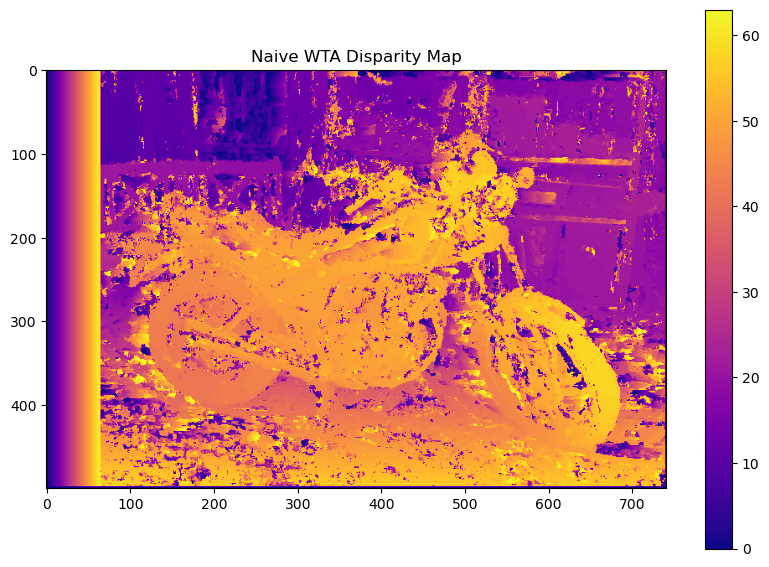

In [6]:
disparity_naive = np.argmin(cost_volume, axis=2)

plt.figure(figsize=(10, 7))
plt.imshow(disparity_naive, cmap='plasma')
plt.colorbar()
plt.title('Naive WTA Disparity Map')
plt.show()